In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
import warnings
warnings.filterwarnings('ignore')

# Configuración de estilos
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 10

print("✓ Librerías importadas exitosamente")
print("✓ Iniciando análisis de People Analytics - FinanCorp Chile")

✓ Librerías importadas exitosamente
✓ Iniciando análisis de People Analytics - FinanCorp Chile


# PEOPLE ANALYTICS: FinanCorp Chile
## Diagnóstico de Rotación, Retención y Fuga de Talento

**Empresa:** FinanCorp Chile (Caso ficticio - Servicios Financieros)  
**Dotación:** 3.200 colaboradores  
**Rotación anual actual:** 22% (~704 salidas)  
**Costo directo de reemplazo:** USD 3.000 por persona  
**Costo anual de rotación:** USD 2.112.000  

### Objetivo del Análisis
Construir una capacidad analítica para identificar, explicar y anticipar la fuga de talento en áreas críticas, permitiendo priorizar acciones de retención con impacto medible en costos y continuidad operacional.

### Metas de Mejora (12 meses)
- Reducir rotación total: -15%
- Reducir fuga en cargos críticos: -20%
- Mejorar retención de alto desempeño: +10%

In [2]:
# ===========================
# 1. GENERACIÓN DE DATOS SINTÉTICOS
# ===========================

np.random.seed(42)

# Parámetros del caso
DOTACION_TOTAL = 3200
ROTACION_ANUAL = 0.22
AREAS_CRITICAS = ['Tecnología', 'Operaciones Financieras', 'Riesgo y Cumplimiento', 'Atención de Clientes']
OTRAS_AREAS = ['Finanzas', 'Personas', 'Legal', 'Administración']
TODAS_AREAS = AREAS_CRITICAS + OTRAS_AREAS

# Distribución de colaboradores por área (realista para empresa financiera)
distribucion_areas = {
    'Tecnología': 0.25,
    'Operaciones Financieras': 0.22,
    'Riesgo y Cumplimiento': 0.18,
    'Atención de Clientes': 0.20,
    'Finanzas': 0.08,
    'Personas': 0.04,
    'Legal': 0.02,
    'Administración': 0.01
}

# Crear dataset de colaboradores
colaboradores = []

for area in TODAS_AREAS:
    cantidad = int(DOTACION_TOTAL * distribucion_areas[area])
    
    for i in range(cantidad):
        # Antigüedad distribuida
        antiguedad_meses = np.random.exponential(scale=30) + 6
        antiguedad_anos = antiguedad_meses / 12
        
        # Variables de desempeño (1-5)
        desempeño = np.clip(np.random.normal(3.2, 0.9), 1, 5)
        
        # Clima laboral (1-5) - correlacionado con área y desempeño
        clima_base = 3.0 if area in AREAS_CRITICAS else 3.5
        clima = np.clip(np.random.normal(clima_base, 0.8), 1, 5)
        
        # Nivel de compromiso (1-5) - correlacionado con desempeño y clima
        compromiso = np.clip(0.4 * desempeño + 0.3 * clima + np.random.normal(0, 0.6), 1, 5)
        
        # Ausentismo (días al año)
        ausentismo = max(0, int(np.random.normal(8, 5) - compromiso * 1.5))
        
        # Movilidad interna (traslados internos en últimos 2 años)
        movilidad_interna = np.random.binomial(1, 0.15)
        
        # Capacitación (cursos en último año)
        capacitacion = int(np.random.exponential(2) + 1)
        
        # Nivel salarial (correlacionado con antigüedad, desempeño y si es cargo crítico)
        es_critico = 1 if area in AREAS_CRITICAS else 0
        salario_base = 2000 + antiguedad_anos * 100 + desempeño * 300 + es_critico * 500
        salario = max(1500, int(np.random.normal(salario_base, 300)))
        
        # Rotación (probabilidad correlacionada con variables)
        # Mayor riesgo: bajo clima, bajo compromiso, bajo desempeño, poco desarrollo
        prob_base = 0.22  # rotación anual del 22%
        prob_rotacion = prob_base * (1 - compromiso/5) * (1 + ausentismo/20) * (1 - capacitacion/5)
        
        rota = 1 if np.random.random() < prob_rotacion else 0
        
        colaboradores.append({
            'id_colaborador': f'CLAB_{area[:3]}_{i:04d}',
            'area': area,
            'es_area_critica': es_critico,
            'antiguedad_anos': round(antiguedad_anos, 2),
            'desempeño': round(desempeño, 1),
            'clima': round(clima, 1),
            'compromiso': round(compromiso, 1),
            'ausentismo_dias': ausentismo,
            'movilidad_interna': movilidad_interna,
            'capacitacion_cursos': capacitacion,
            'salario_usd': salario,
            'rotacion': rota
        })

df = pd.DataFrame(colaboradores)

print(f"✓ Dataset generado: {len(df)} colaboradores")
print(f"\nDistribución por área:")
print(df['area'].value_counts().sort_index())
print(f"\nRotación actual: {df['rotacion'].mean()*100:.1f}%")
print(f"Rotación en áreas críticas: {df[df['es_area_critica']==1]['rotacion'].mean()*100:.1f}%")

✓ Dataset generado: 3200 colaboradores

Distribución por área:
area
Administración              32
Atención de Clientes       640
Finanzas                   256
Legal                       64
Operaciones Financieras    704
Personas                   128
Riesgo y Cumplimiento      576
Tecnología                 800
Name: count, dtype: int64

Rotación actual: 8.4%
Rotación en áreas críticas: 8.7%


## 2. ANÁLISIS EXPLORATORIO DE DATOS (EDA)

In [3]:
# Estadísticas descriptivas
print("="*80)
print("ESTADÍSTICAS DESCRIPTIVAS DEL DATASET")
print("="*80)
print("\nVariables numéricas:")
print(df[['antiguedad_anos', 'desempeño', 'clima', 'compromiso', 'ausentismo_dias', 'salario_usd']].describe())

print("\n\nDistribución de variables categóricas:")
print(f"\nÁreas críticas vs otras: {df['es_area_critica'].value_counts().to_dict()}")
print(f"Rotación - Sí/No: {df['rotacion'].value_counts().to_dict()}")

# Correlaciones
print("\n\nCorrelaciones con Rotación:")
correlaciones = df[['antiguedad_anos', 'desempeño', 'clima', 'compromiso', 
                     'ausentismo_dias', 'movilidad_interna', 'capacitacion_cursos', 
                     'es_area_critica', 'rotacion']].corr()['rotacion'].sort_values(ascending=False)
print(correlaciones)

ESTADÍSTICAS DESCRIPTIVAS DEL DATASET

Variables numéricas:
       antiguedad_anos    desempeño        clima   compromiso  \
count      3200.000000  3200.000000  3200.000000  3200.000000   
mean          3.004759     3.165250     3.056875     2.198625   
std           2.413286     0.878768     0.831463     0.694873   
min           0.500000     1.000000     1.000000     1.000000   
25%           1.250000     2.600000     2.500000     1.700000   
50%           2.280000     3.200000     3.100000     2.200000   
75%           3.990000     3.800000     3.600000     2.700000   
max          20.740000     5.000000     5.000000     4.800000   

       ausentismo_dias  salario_usd  
count       3200.00000  3200.000000  
mean           4.88625  3676.530313  
std            4.31680   501.297767  
min            0.00000  2090.000000  
25%            1.00000  3344.750000  
50%            4.00000  3675.000000  
75%            8.00000  4006.000000  
max           24.00000  6088.000000  


Distribuci

## 3. INDICADORES CLAVE DE ROTACIÓN

In [4]:
# === INDICADORES GLOBALES ===
rotacion_total = df['rotacion'].mean() * 100
rotacion_critica = df[df['es_area_critica']==1]['rotacion'].mean() * 100
rotacion_otras = df[df['es_area_critica']==0]['rotacion'].mean() * 100

salidas_anuales = int(df['rotacion'].sum())
costo_directo_reemplazo = 3000
costo_rotacion_anual = salidas_anuales * costo_directo_reemplazo

print("="*80)
print("INDICADORES GLOBALES DE ROTACIÓN")
print("="*80)
print(f"\n1. ROTACIÓN TOTAL: {rotacion_total:.1f}%")
print(f"   - Salidas anuales estimadas: {salidas_anuales} personas")
print(f"   - Costo directo anual: USD ${costo_rotacion_anual:,}")

print(f"\n2. ROTACIÓN POR CRITICIDAD:")
print(f"   - Áreas críticas: {rotacion_critica:.1f}%")
print(f"   - Otras áreas: {rotacion_otras:.1f}%")
print(f"   - DIFERENCIAL: {(rotacion_critica - rotacion_otras):.1f} puntos porcentuales")

# === ROTACIÓN POR ÁREA ===
print(f"\n3. ROTACIÓN POR ÁREA:")
rotacion_area = df.groupby('area')['rotacion'].agg(['sum', 'mean', 'count'])
rotacion_area.columns = ['Salidas', 'Tasa (%)', 'Total']
rotacion_area['Tasa (%)'] = rotacion_area['Tasa (%)'] * 100
rotacion_area = rotacion_area.sort_values('Tasa (%)', ascending=False)
print(rotacion_area)

# === ROTACIÓN POR ANTIGÜEDAD ===
df['tramo_antiguedad'] = pd.cut(df['antiguedad_anos'], 
                                 bins=[0, 1, 2, 5, 10, float('inf')],
                                 labels=['0-1 año', '1-2 años', '2-5 años', '5-10 años', '+10 años'])

print(f"\n4. ROTACIÓN POR ANTIGÜEDAD:")
rotacion_antiguedad = df.groupby('tramo_antiguedad')['rotacion'].agg(['count', 'sum', 'mean'])
rotacion_antiguedad.columns = ['Total', 'Rotados', 'Tasa (%)']
rotacion_antiguedad['Tasa (%)'] = rotacion_antiguedad['Tasa (%)'] * 100
print(rotacion_antiguedad)

# === ROTACIÓN POR DESEMPEÑO ===
df['tramo_desempeño'] = pd.cut(df['desempeño'], 
                                bins=[0, 2, 3, 4, 5],
                                labels=['Bajo (1-2)', 'Medio (2-3)', 'Bueno (3-4)', 'Excelente (4-5)'])

print(f"\n5. ROTACIÓN POR NIVEL DE DESEMPEÑO:")
rotacion_desempeño = df.groupby('tramo_desempeño')['rotacion'].agg(['count', 'sum', 'mean'])
rotacion_desempeño.columns = ['Total', 'Rotados', 'Tasa (%)']
rotacion_desempeño['Tasa (%)'] = rotacion_desempeño['Tasa (%)'] * 100
print(rotacion_desempeño)

# === IMPACTO FINANCIERO ESTIMADO ===
print(f"\n6. ANÁLISIS FINANCIERO:")
print(f"   - Costo actual de rotación: USD ${costo_rotacion_anual:,}")
print(f"   - Si reducimos 15%: evitamos {int(salidas_anuales * 0.15)} salidas")
print(f"   - Ahorro directo potencial: USD ${int(salidas_anuales * 0.15 * costo_directo_reemplazo):,}")
print(f"   - Si reducimos fuga en áreas críticas 20%:")
salidas_criticas = df[df['es_area_critica']==1]['rotacion'].sum()
print(f"     * Salidas actuales en áreas críticas: {int(salidas_criticas)}")
print(f"     * Evitaríamos: {int(salidas_criticas * 0.20)} salidas")
print(f"     * Ahorro adicional: USD ${int(salidas_criticas * 0.20 * costo_directo_reemplazo):,}")

INDICADORES GLOBALES DE ROTACIÓN

1. ROTACIÓN TOTAL: 8.4%
   - Salidas anuales estimadas: 270 personas
   - Costo directo anual: USD $810,000

2. ROTACIÓN POR CRITICIDAD:
   - Áreas críticas: 8.7%
   - Otras áreas: 7.1%
   - DIFERENCIAL: 1.6 puntos porcentuales

3. ROTACIÓN POR ÁREA:
                         Salidas  Tasa (%)  Total
area                                             
Riesgo y Cumplimiento         56  9.722222    576
Tecnología                    75  9.375000    800
Atención de Clientes          55  8.593750    640
Finanzas                      22  8.593750    256
Operaciones Financieras       50  7.102273    704
Personas                       9  7.031250    128
Legal                          2  3.125000     64
Administración                 1  3.125000     32

4. ROTACIÓN POR ANTIGÜEDAD:
                  Total  Rotados  Tasa (%)
tramo_antiguedad                          
0-1 año             580       45  7.758621
1-2 años            831       74  8.904934
2-5 años      

## 4. ANÁLISIS DIAGNÓSTICO - VISUALIZACIONES

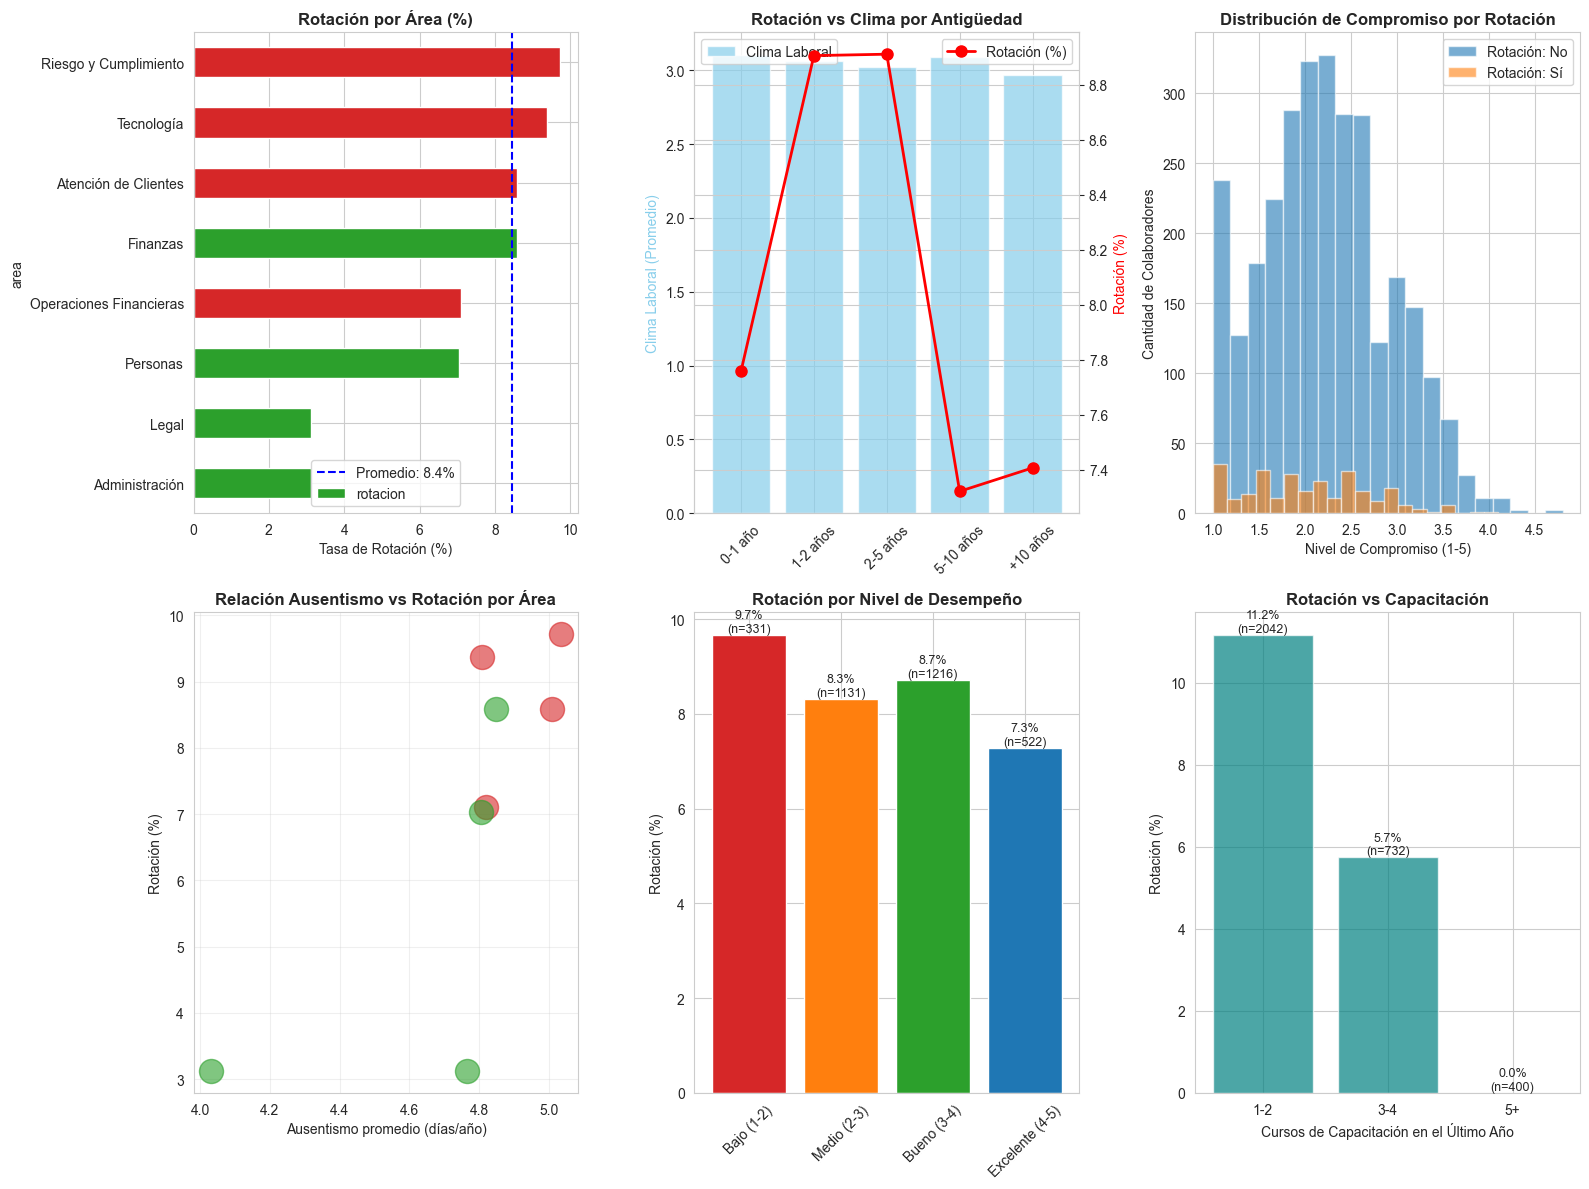

✓ Gráficos diagnósticos generados


In [5]:
# Crear figura con múltiples subplots
fig = plt.figure(figsize=(16, 12))

# 1. Rotación por Área
ax1 = plt.subplot(2, 3, 1)
rotacion_x_area = df.groupby('area')['rotacion'].mean() * 100
rotacion_x_area = rotacion_x_area.sort_values(ascending=True)
colores = ['#d62728' if df[df['area']==area]['es_area_critica'].iloc[0]==1 else '#2ca02c' 
           for area in rotacion_x_area.index]
rotacion_x_area.plot(kind='barh', ax=ax1, color=colores)
ax1.set_title('Rotación por Área (%)', fontsize=12, fontweight='bold')
ax1.set_xlabel('Tasa de Rotación (%)')
ax1.axvline(rotacion_total, color='blue', linestyle='--', label=f'Promedio: {rotacion_total:.1f}%')
ax1.legend()

# 2. Rotación vs Clima Laboral
ax2 = plt.subplot(2, 3, 2)
clima_rotacion = df.groupby('tramo_antiguedad')['clima'].mean()
rotacion_x_tramo = df.groupby('tramo_antiguedad')['rotacion'].mean() * 100
ax2_twin = ax2.twinx()
ax2.bar(range(len(clima_rotacion)), clima_rotacion.values, alpha=0.7, label='Clima Laboral', color='skyblue')
ax2_twin.plot(range(len(rotacion_x_tramo)), rotacion_x_tramo.values, 'ro-', linewidth=2, label='Rotación (%)', markersize=8)
ax2.set_xticks(range(len(clima_rotacion)))
ax2.set_xticklabels(clima_rotacion.index, rotation=45)
ax2.set_ylabel('Clima Laboral (Promedio)', color='skyblue')
ax2_twin.set_ylabel('Rotación (%)', color='red')
ax2.set_title('Rotación vs Clima por Antigüedad', fontsize=12, fontweight='bold')
ax2.legend(loc='upper left')
ax2_twin.legend(loc='upper right')

# 3. Rotación vs Compromiso
ax3 = plt.subplot(2, 3, 3)
for rotacion_val in [0, 1]:
    label = 'Rotación: Sí' if rotacion_val == 1 else 'Rotación: No'
    data = df[df['rotacion'] == rotacion_val]['compromiso']
    ax3.hist(data, bins=20, alpha=0.6, label=label)
ax3.set_xlabel('Nivel de Compromiso (1-5)')
ax3.set_ylabel('Cantidad de Colaboradores')
ax3.set_title('Distribución de Compromiso por Rotación', fontsize=12, fontweight='bold')
ax3.legend()

# 4. Ausentismo vs Rotación
ax4 = plt.subplot(2, 3, 4)
scatter_data = df.groupby('area')['ausentismo_dias'].mean()
rotacion_data = df.groupby('area')['rotacion'].mean() * 100
colores_scatter = ['#d62728' if df[df['area']==area]['es_area_critica'].iloc[0]==1 else '#2ca02c' 
                   for area in scatter_data.index]
for area, color in zip(scatter_data.index, colores_scatter):
    ax4.scatter(scatter_data[area], rotacion_data[area], s=300, alpha=0.6, color=color, label=area)
ax4.set_xlabel('Ausentismo promedio (días/año)')
ax4.set_ylabel('Rotación (%)')
ax4.set_title('Relación Ausentismo vs Rotación por Área', fontsize=12, fontweight='bold')
ax4.grid(True, alpha=0.3)

# 5. Desempeño vs Rotación
ax5 = plt.subplot(2, 3, 5)
desempeño_rotacion = df.groupby('tramo_desempeño')['rotacion'].mean() * 100
desempeño_count = df.groupby('tramo_desempeño').size()
bars = ax5.bar(range(len(desempeño_rotacion)), desempeño_rotacion.values, color=['#d62728', '#ff7f0e', '#2ca02c', '#1f77b4'])
ax5.set_xticks(range(len(desempeño_rotacion)))
ax5.set_xticklabels(desempeño_rotacion.index, rotation=45)
ax5.set_ylabel('Rotación (%)')
ax5.set_title('Rotación por Nivel de Desempeño', fontsize=12, fontweight='bold')
for i, (bar, count) in enumerate(zip(bars, desempeño_count)):
    height = bar.get_height()
    ax5.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.1f}%\n(n={count})',
            ha='center', va='bottom', fontsize=9)

# 6. Capacitación vs Rotación
ax6 = plt.subplot(2, 3, 6)
df['tramo_capacitacion'] = pd.cut(df['capacitacion_cursos'], bins=[-1, 0, 2, 4, 10], 
                                   labels=['0', '1-2', '3-4', '5+'])
cap_rotacion = df.groupby('tramo_capacitacion')['rotacion'].mean() * 100
cap_count = df.groupby('tramo_capacitacion').size()
bars = ax6.bar(range(len(cap_rotacion)), cap_rotacion.values, color='teal', alpha=0.7)
ax6.set_xticks(range(len(cap_rotacion)))
ax6.set_xticklabels(cap_rotacion.index)
ax6.set_ylabel('Rotación (%)')
ax6.set_xlabel('Cursos de Capacitación en el Último Año')
ax6.set_title('Rotación vs Capacitación', fontsize=12, fontweight='bold')
for i, (bar, count) in enumerate(zip(bars, cap_count)):
    height = bar.get_height()
    ax6.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.1f}%\n(n={count})',
            ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('analisis_diagnostico.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Gráficos diagnósticos generados")

## 5. SEGMENTACIÓN Y ANÁLISIS DE RIESGO

In [6]:
# === CREAR PERFILES DE RIESGO ===
# Definir criterios de riesgo de fuga
def calcular_score_riesgo(row):
    """Calcula un score de riesgo de fuga (0-100)"""
    score = 0
    
    # Compromiso bajo (peso: 35)
    if row['compromiso'] < 2.5:
        score += 35
    elif row['compromiso'] < 3.0:
        score += 20
    
    # Ausentismo alto (peso: 25)
    if row['ausentismo_dias'] > 12:
        score += 25
    elif row['ausentismo_dias'] > 8:
        score += 15
    
    # Bajo desempeño (peso: 20)
    if row['desempeño'] < 2.5:
        score += 20
    elif row['desempeño'] < 3.0:
        score += 10
    
    # Falta de capacitación (peso: 10)
    if row['capacitacion_cursos'] < 1:
        score += 10
    
    # Baja movilidad interna + antigüedad media (peso: 10)
    if row['movilidad_interna'] == 0 and row['antiguedad_anos'] > 3:
        score += 5
    
    # En área crítica aumenta riesgo (peso: 10 adicionales)
    if row['es_area_critica'] == 1:
        score += 5
    
    return min(score, 100)

df['score_riesgo'] = df.apply(calcular_score_riesgo, axis=1)
df['nivel_riesgo'] = pd.cut(df['score_riesgo'], 
                             bins=[0, 25, 50, 75, 100],
                             labels=['Bajo', 'Medio', 'Alto', 'Muy Alto'])

print("="*80)
print("ANÁLISIS DE SEGMENTACIÓN POR RIESGO DE FUGA")
print("="*80)

# Distribución de riesgo
print(f"\nDistribución por nivel de riesgo:")
riesgo_dist = df['nivel_riesgo'].value_counts().sort_index()
print(riesgo_dist)

# Correlación entre score de riesgo y rotación real
correlacion_riesgo = df['score_riesgo'].corr(df['rotacion'])
print(f"\nCorrelación entre score de riesgo y rotación real: {correlacion_riesgo:.3f}")

# Rotación por nivel de riesgo
print(f"\nRotación por nivel de riesgo:")
rotacion_x_riesgo = df.groupby('nivel_riesgo')['rotacion'].agg(['count', 'sum', 'mean'])
rotacion_x_riesgo.columns = ['Total', 'Rotados', 'Tasa (%)']
rotacion_x_riesgo['Tasa (%)'] = rotacion_x_riesgo['Tasa (%)'] * 100
print(rotacion_x_riesgo)

# Segmentación por área y riesgo
print(f"\nRiesgo por área:")
riesgo_x_area = df.groupby('area')['score_riesgo'].agg(['mean', 'min', 'max']).round(1)
riesgo_x_area.columns = ['Promedio', 'Mínimo', 'Máximo']
riesgo_x_area = riesgo_x_area.sort_values('Promedio', ascending=False)
print(riesgo_x_area)

# Identificar colaboradores de ALTO y MUY ALTO riesgo
alto_riesgo = df[(df['nivel_riesgo'].isin(['Alto', 'Muy Alto']))]
print(f"\n\nCOLABORADORES EN RIESGO (Alto + Muy Alto):")
print(f"Total: {len(alto_riesgo)} personas ({len(alto_riesgo)/len(df)*100:.1f}%)")
print(f"Rotación real en este grupo: {alto_riesgo['rotacion'].mean()*100:.1f}%")
print(f"\nDistribución por área:")
print(alto_riesgo['area'].value_counts())

# Análisis de los alto riesgo rotados
alto_riesgo_rotados = alto_riesgo[alto_riesgo['rotacion'] == 1]
print(f"\nColaboradores alto riesgo que sí rotaron: {len(alto_riesgo_rotados)}")
print(f"Esto representa el {len(alto_riesgo_rotados)/df['rotacion'].sum()*100:.1f}% de todas las rotaciones")

ANÁLISIS DE SEGMENTACIÓN POR RIESGO DE FUGA

Distribución por nivel de riesgo:
nivel_riesgo
Bajo         724
Medio       1385
Alto         966
Muy Alto      79
Name: count, dtype: int64

Correlación entre score de riesgo y rotación real: 0.065

Rotación por nivel de riesgo:
              Total  Rotados   Tasa (%)
nivel_riesgo                           
Bajo            724       44   6.077348
Medio          1385      113   8.158845
Alto            966       95   9.834369
Muy Alto         79       14  17.721519

Riesgo por área:
                         Promedio  Mínimo  Máximo
area                                             
Tecnología                   43.8       5      90
Atención de Clientes         43.5       5      90
Riesgo y Cumplimiento        43.3       5      90
Operaciones Financieras      43.2       5      90
Legal                        40.2       0      70
Finanzas                     36.4       0      85
Personas                     35.5       0      75
Administración   

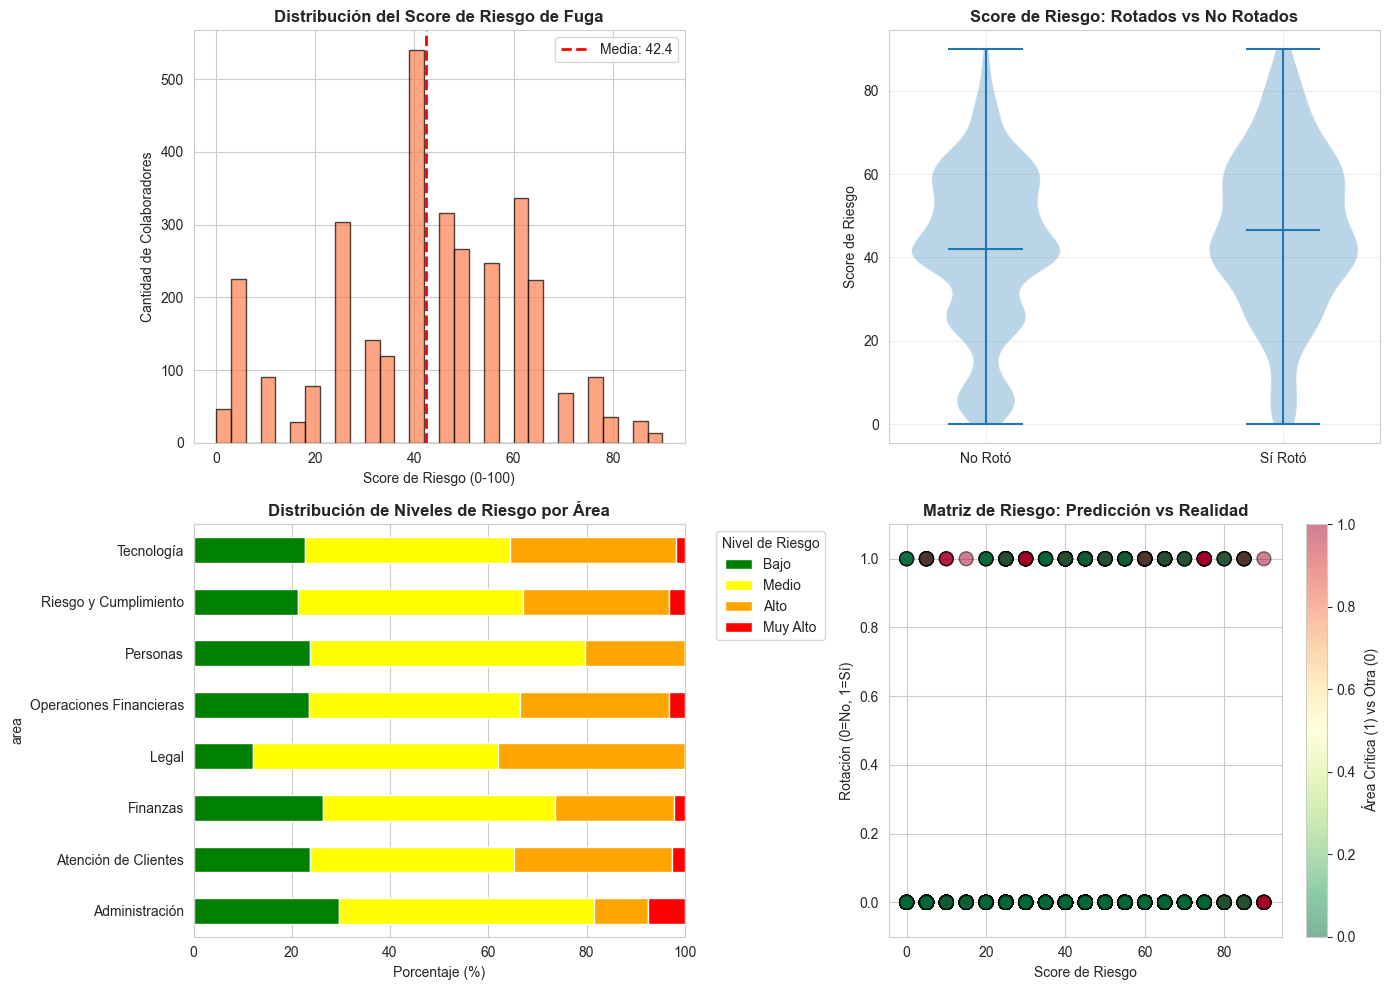

✓ Gráficos de riesgo generados


In [7]:
# Visualizaciones de riesgo
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Distribución del Score de Riesgo
ax = axes[0, 0]
ax.hist(df['score_riesgo'], bins=30, color='coral', edgecolor='black', alpha=0.7)
ax.axvline(df['score_riesgo'].mean(), color='red', linestyle='--', linewidth=2, label=f'Media: {df["score_riesgo"].mean():.1f}')
ax.set_xlabel('Score de Riesgo (0-100)')
ax.set_ylabel('Cantidad de Colaboradores')
ax.set_title('Distribución del Score de Riesgo de Fuga', fontweight='bold')
ax.legend()

# 2. Rotación real vs Score de Riesgo
ax = axes[0, 1]
rotacion_si = df[df['rotacion'] == 1]['score_riesgo']
rotacion_no = df[df['rotacion'] == 0]['score_riesgo']
ax.violinplot([rotacion_no, rotacion_si], positions=[0, 1], showmeans=True)
ax.set_xticks([0, 1])
ax.set_xticklabels(['No Rotó', 'Sí Rotó'])
ax.set_ylabel('Score de Riesgo')
ax.set_title('Score de Riesgo: Rotados vs No Rotados', fontweight='bold')
ax.grid(True, alpha=0.3)

# 3. Nivel de Riesgo por Área
ax = axes[1, 0]
riesgo_area_crosstab = pd.crosstab(df['area'], df['nivel_riesgo'], normalize='index') * 100
riesgo_area_crosstab.plot(kind='barh', stacked=True, ax=ax, color=['green', 'yellow', 'orange', 'red'])
ax.set_xlabel('Porcentaje (%)')
ax.set_title('Distribución de Niveles de Riesgo por Área', fontweight='bold')
ax.legend(title='Nivel de Riesgo', bbox_to_anchor=(1.05, 1), loc='upper left')

# 4. Matriz de Riesgo: Score vs Rotación Real
ax = axes[1, 1]
scatter = ax.scatter(df['score_riesgo'], df['rotacion'], 
                     c=df['es_area_critica'], cmap='RdYlGn_r', 
                     s=100, alpha=0.5, edgecolors='black')
ax.set_xlabel('Score de Riesgo')
ax.set_ylabel('Rotación (0=No, 1=Sí)')
ax.set_ylim(-0.1, 1.1)
ax.set_title('Matriz de Riesgo: Predicción vs Realidad', fontweight='bold')
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Área Crítica (1) vs Otra (0)')

plt.tight_layout()
plt.savefig('analisis_riesgo.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Gráficos de riesgo generados")

## 6. MODELO PREDICTIVO DE RIESGO DE FUGA (MACHINE LEARNING)

In [8]:
# === PREPARACIÓN DE DATOS PARA MODELO ===

# Seleccionar features relevantes
features_modelo = ['antiguedad_anos', 'desempeño', 'clima', 'compromiso', 
                   'ausentismo_dias', 'movilidad_interna', 'capacitacion_cursos', 'es_area_critica']

X = df[features_modelo].copy()
y = df['rotacion'].copy()

# Normalizar features numéricas
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=features_modelo)

# Dividir en train-test (80-20)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)

print("="*80)
print("MODELO PREDICTIVO DE RIESGO DE FUGA")
print("="*80)
print(f"\nDataset de entrenamiento: {len(X_train)} observaciones")
print(f"Dataset de prueba: {len(X_test)} observaciones")
print(f"Balanceo de clases en train: {y_train.mean()*100:.1f}% rotación")
print(f"Balanceo de clases en test: {y_test.mean()*100:.1f}% rotación")

# === ENTRENAR MODELOS ===

# 1. Regresión Logística
print(f"\n\n{'='*80}")
print("MODELO 1: REGRESIÓN LOGÍSTICA")
print(f"{'='*80}")

lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train, y_train)

# Predicciones
y_pred_lr = lr_model.predict(X_test)
y_pred_proba_lr = lr_model.predict_proba(X_test)[:, 1]

# Métricas
print(f"\nPrecisión en test: {lr_model.score(X_test, y_test):.3f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_pred_proba_lr):.3f}")
print(f"\nReporte de clasificación:")
print(classification_report(y_test, y_pred_lr, target_names=['No Rotación', 'Rotación']))

# Importancia de features en Regresión Logística
coeficientes_lr = pd.DataFrame({
    'Feature': features_modelo,
    'Coeficiente': lr_model.coef_[0]
}).sort_values('Coeficiente', ascending=False)

print(f"\nImportancia de Features (Coeficientes):")
print(coeficientes_lr)

# 2. Random Forest
print(f"\n\n{'='*80}")
print("MODELO 2: RANDOM FOREST")
print(f"{'='*80}")

rf_model = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=10, min_samples_leaf=5)
rf_model.fit(X_train, y_train)

# Predicciones
y_pred_rf = rf_model.predict(X_test)
y_pred_proba_rf = rf_model.predict_proba(X_test)[:, 1]

# Métricas
print(f"\nPrecisión en test: {rf_model.score(X_test, y_test):.3f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_pred_proba_rf):.3f}")
print(f"\nReporte de clasificación:")
print(classification_report(y_test, y_pred_rf, target_names=['No Rotación', 'Rotación']))

# Importancia de features en Random Forest
importancia_rf = pd.DataFrame({
    'Feature': features_modelo,
    'Importancia': rf_model.feature_importances_
}).sort_values('Importancia', ascending=False)

print(f"\nImportancia de Features:")
print(importancia_rf)

# Comparar modelos
print(f"\n\n{'='*80}")
print("COMPARACIÓN DE MODELOS")
print(f"{'='*80}")
print(f"\n{'Modelo':<25} {'Precisión':<15} {'ROC-AUC':<15}")
print(f"{'-'*55}")
print(f"{'Regresión Logística':<25} {lr_model.score(X_test, y_test):<15.3f} {roc_auc_score(y_test, y_pred_proba_lr):<15.3f}")
print(f"{'Random Forest':<25} {rf_model.score(X_test, y_test):<15.3f} {roc_auc_score(y_test, y_pred_proba_rf):<15.3f}")

# Usar el mejor modelo (Random Forest en este caso)
mejor_modelo = rf_model
y_pred_proba = y_pred_proba_rf

print(f"\n✓ Se utiliza Random Forest como modelo final para predicciones")

MODELO PREDICTIVO DE RIESGO DE FUGA

Dataset de entrenamiento: 2560 observaciones
Dataset de prueba: 640 observaciones
Balanceo de clases en train: 8.4% rotación
Balanceo de clases en test: 8.4% rotación


MODELO 1: REGRESIÓN LOGÍSTICA

Precisión en test: 0.916
ROC-AUC: 0.682

Reporte de clasificación:
              precision    recall  f1-score   support

 No Rotación       0.92      1.00      0.96       586
    Rotación       0.00      0.00      0.00        54

    accuracy                           0.92       640
   macro avg       0.46      0.50      0.48       640
weighted avg       0.84      0.92      0.88       640


Importancia de Features (Coeficientes):
               Feature  Coeficiente
4      ausentismo_dias     0.252918
1            desempeño     0.041658
7      es_area_critica     0.030978
2                clima     0.002503
5    movilidad_interna    -0.032695
0      antiguedad_anos    -0.056084
3           compromiso    -0.271852
6  capacitacion_cursos    -0.811749


MO

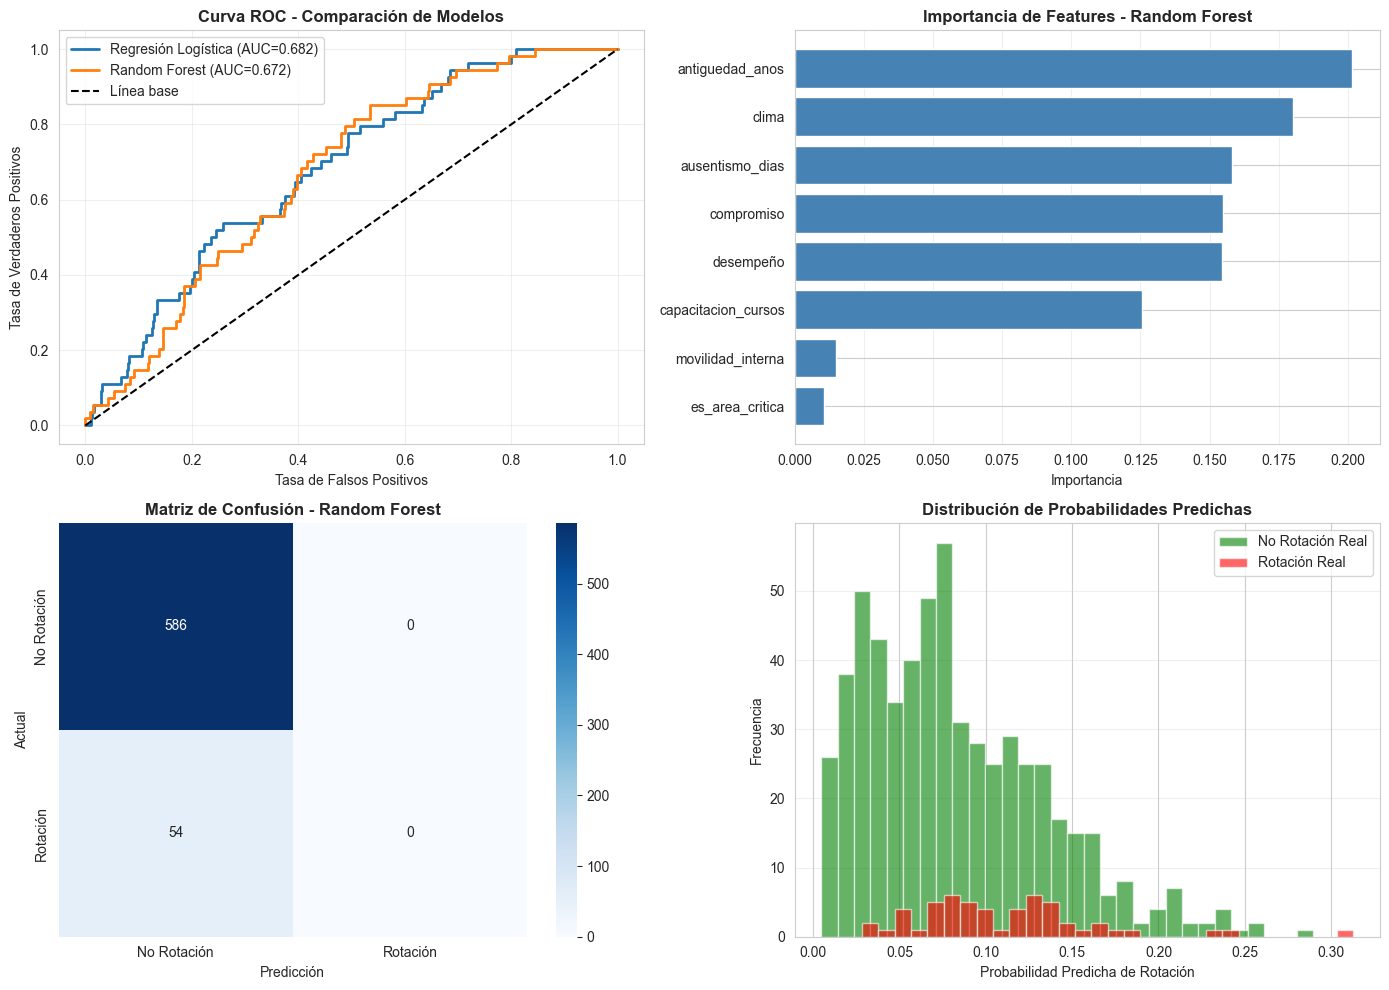

✓ Gráficos de modelos predictivos generados


In [9]:
# Visualizaciones de Modelos
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Curva ROC - Comparación de modelos
ax = axes[0, 0]
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_pred_proba_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_pred_proba_rf)
ax.plot(fpr_lr, tpr_lr, label=f'Regresión Logística (AUC={roc_auc_score(y_test, y_pred_proba_lr):.3f})', linewidth=2)
ax.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC={roc_auc_score(y_test, y_pred_proba_rf):.3f})', linewidth=2)
ax.plot([0, 1], [0, 1], 'k--', label='Línea base')
ax.set_xlabel('Tasa de Falsos Positivos')
ax.set_ylabel('Tasa de Verdaderos Positivos')
ax.set_title('Curva ROC - Comparación de Modelos', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# 2. Importancia de Features (Random Forest)
ax = axes[0, 1]
importancia_rf_sorted = importancia_rf.sort_values('Importancia')
ax.barh(importancia_rf_sorted['Feature'], importancia_rf_sorted['Importancia'], color='steelblue')
ax.set_xlabel('Importancia')
ax.set_title('Importancia de Features - Random Forest', fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')

# 3. Matriz de Confusión
ax = axes[1, 0]
cm = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, 
            xticklabels=['No Rotación', 'Rotación'],
            yticklabels=['No Rotación', 'Rotación'])
ax.set_ylabel('Actual')
ax.set_xlabel('Predicción')
ax.set_title('Matriz de Confusión - Random Forest', fontweight='bold')

# 4. Distribución de Probabilidades Predichas
ax = axes[1, 1]
ax.hist(y_pred_proba_rf[y_test == 0], bins=30, alpha=0.6, label='No Rotación Real', color='green')
ax.hist(y_pred_proba_rf[y_test == 1], bins=30, alpha=0.6, label='Rotación Real', color='red')
ax.set_xlabel('Probabilidad Predicha de Rotación')
ax.set_ylabel('Frecuencia')
ax.set_title('Distribución de Probabilidades Predichas', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('modelos_predictivos.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Gráficos de modelos predictivos generados")

## 7. ANÁLISIS DE ÁREAS CRÍTICAS Y PRIORIZACIÓN

In [10]:
# Aplicar modelo predictivo a todo el dataset
df['prob_rotacion_modelo'] = mejor_modelo.predict_proba(X_scaled)[:, 1]
df['riesgo_predicho'] = pd.cut(df['prob_rotacion_modelo'], 
                               bins=[0, 0.25, 0.5, 0.75, 1.0],
                               labels=['Bajo', 'Medio', 'Alto', 'Muy Alto'])

print("="*80)
print("ANÁLISIS DETALLADO DE ÁREAS CRÍTICAS")
print("="*80)

for area in AREAS_CRITICAS:
    datos_area = df[df['area'] == area]
    print(f"\n{'-'*80}")
    print(f"ÁREA: {area}")
    print(f"{'-'*80}")
    print(f"Total colaboradores: {len(datos_area)}")
    print(f"Rotación actual: {datos_area['rotacion'].mean()*100:.1f}%")
    print(f"Salidas estimadas: {datos_area['rotacion'].sum():.0f} personas")
    print(f"Costo de rotación: USD ${(datos_area['rotacion'].sum() * 3000):.0f}")
    
    print(f"\nDistribución de riesgo:")
    riesgo_dist = datos_area['riesgo_predicho'].value_counts().sort_index(ascending=False)
    for nivel, cantidad in riesgo_dist.items():
        print(f"  {nivel}: {cantidad} personas ({cantidad/len(datos_area)*100:.1f}%)")
    
    # Personas en alto riesgo
    alto_riesgo_area = datos_area[datos_area['riesgo_predicho'].isin(['Alto', 'Muy Alto'])]
    print(f"\nPersonas en Alto/Muy Alto riesgo: {len(alto_riesgo_area)}")
    
    # Variables más críticas en esta área
    print(f"\nPromedio de variables clave:")
    print(f"  Compromiso: {datos_area['compromiso'].mean():.2f}/5.0")
    print(f"  Desempeño: {datos_area['desempeño'].mean():.2f}/5.0")
    print(f"  Clima: {datos_area['clima'].mean():.2f}/5.0")
    print(f"  Ausentismo: {datos_area['ausentismo_dias'].mean():.1f} días/año")
    print(f"  Capacitación: {datos_area['capacitacion_cursos'].mean():.1f} cursos/año")
    print(f"  Movilidad interna: {datos_area['movilidad_interna'].mean()*100:.1f}% con movimiento")

# === TABLERO EJECUTIVO DE PRIORIZACIÓN ===
print(f"\n\n{'='*80}")
print("TABLERO EJECUTIVO - PRIORIZACIÓN DE INTERVENCIONES")
print(f"{'='*80}")

# Crear matriz de priorización
df['impacto_estimado'] = df['es_area_critica'] * 1000 + df['salario_usd'] * 0.1
df['urgencia'] = df['prob_rotacion_modelo'] * df['salario_usd']

# Top 20 personas en mayor riesgo
top_riesgo = df.nlargest(20, 'urgencia')[['id_colaborador', 'area', 'desempeño', 'clima', 
                                           'compromiso', 'ausentismo_dias', 'salario_usd', 
                                           'prob_rotacion_modelo', 'riesgo_predicho']]

print("\nTOP 20 PERSONAS CON MAYOR RIESGO DE FUGA (Por impacto potencial):")
print(top_riesgo.to_string(index=False))

# Resumen por nivel de intervención
print(f"\n\nRESUMEN DE INTERVENCIONES RECOMENDADAS:")
print(f"{'-'*80}")

# Nivel 1: Muy Alto riesgo
muy_alto_riesgo = df[df['riesgo_predicho'] == 'Muy Alto']
print(f"\nNIVEL 1 - INTERVENCIÓN INMEDIATA (Riesgo Muy Alto):")
print(f"  Total: {len(muy_alto_riesgo)} personas")
print(f"  Impacto si se van: USD ${muy_alto_riesgo['salario_usd'].sum():.0f}")
print(f"  Costo estimado de reemplazo: USD ${len(muy_alto_riesgo) * 3000:.0f}")
print(f"  Acciones: Reuniones 1-a-1, planes de desarrollo, ajustes salariales")

# Nivel 2: Alto riesgo
alto_riesgo_2 = df[df['riesgo_predicho'] == 'Alto']
print(f"\nNIVEL 2 - INTERVENCIÓN PREVENTIVA (Riesgo Alto):")
print(f"  Total: {len(alto_riesgo_2)} personas")
print(f"  Impacto si se van: USD ${alto_riesgo_2['salario_usd'].sum():.0f}")
print(f"  Costo estimado de reemplazo: USD ${len(alto_riesgo_2) * 3000:.0f}")
print(f"  Acciones: Check-ins regulares, planes de capacitación, evaluación de clima")

# Nivel 3: Medio riesgo
medio_riesgo = df[df['riesgo_predicho'] == 'Medio']
print(f"\nNIVEL 3 - MONITOREO ACTIVO (Riesgo Medio):")
print(f"  Total: {len(medio_riesgo)} personas")
print(f"  Acciones: Seguimiento trimestral, oportunidades de crecimiento")

ANÁLISIS DETALLADO DE ÁREAS CRÍTICAS

--------------------------------------------------------------------------------
ÁREA: Tecnología
--------------------------------------------------------------------------------
Total colaboradores: 800
Rotación actual: 9.4%
Salidas estimadas: 75 personas
Costo de rotación: USD $225000

Distribución de riesgo:
  Muy Alto: 0 personas (0.0%)
  Alto: 0 personas (0.0%)
  Medio: 14 personas (1.8%)
  Bajo: 786 personas (98.2%)

Personas en Alto/Muy Alto riesgo: 0

Promedio de variables clave:
  Compromiso: 2.16/5.0
  Desempeño: 3.15/5.0
  Clima: 2.98/5.0
  Ausentismo: 4.8 días/año
  Capacitación: 2.4 cursos/año
  Movilidad interna: 16.8% con movimiento

--------------------------------------------------------------------------------
ÁREA: Operaciones Financieras
--------------------------------------------------------------------------------
Total colaboradores: 704
Rotación actual: 7.1%
Salidas estimadas: 50 personas
Costo de rotación: USD $150000

Dis

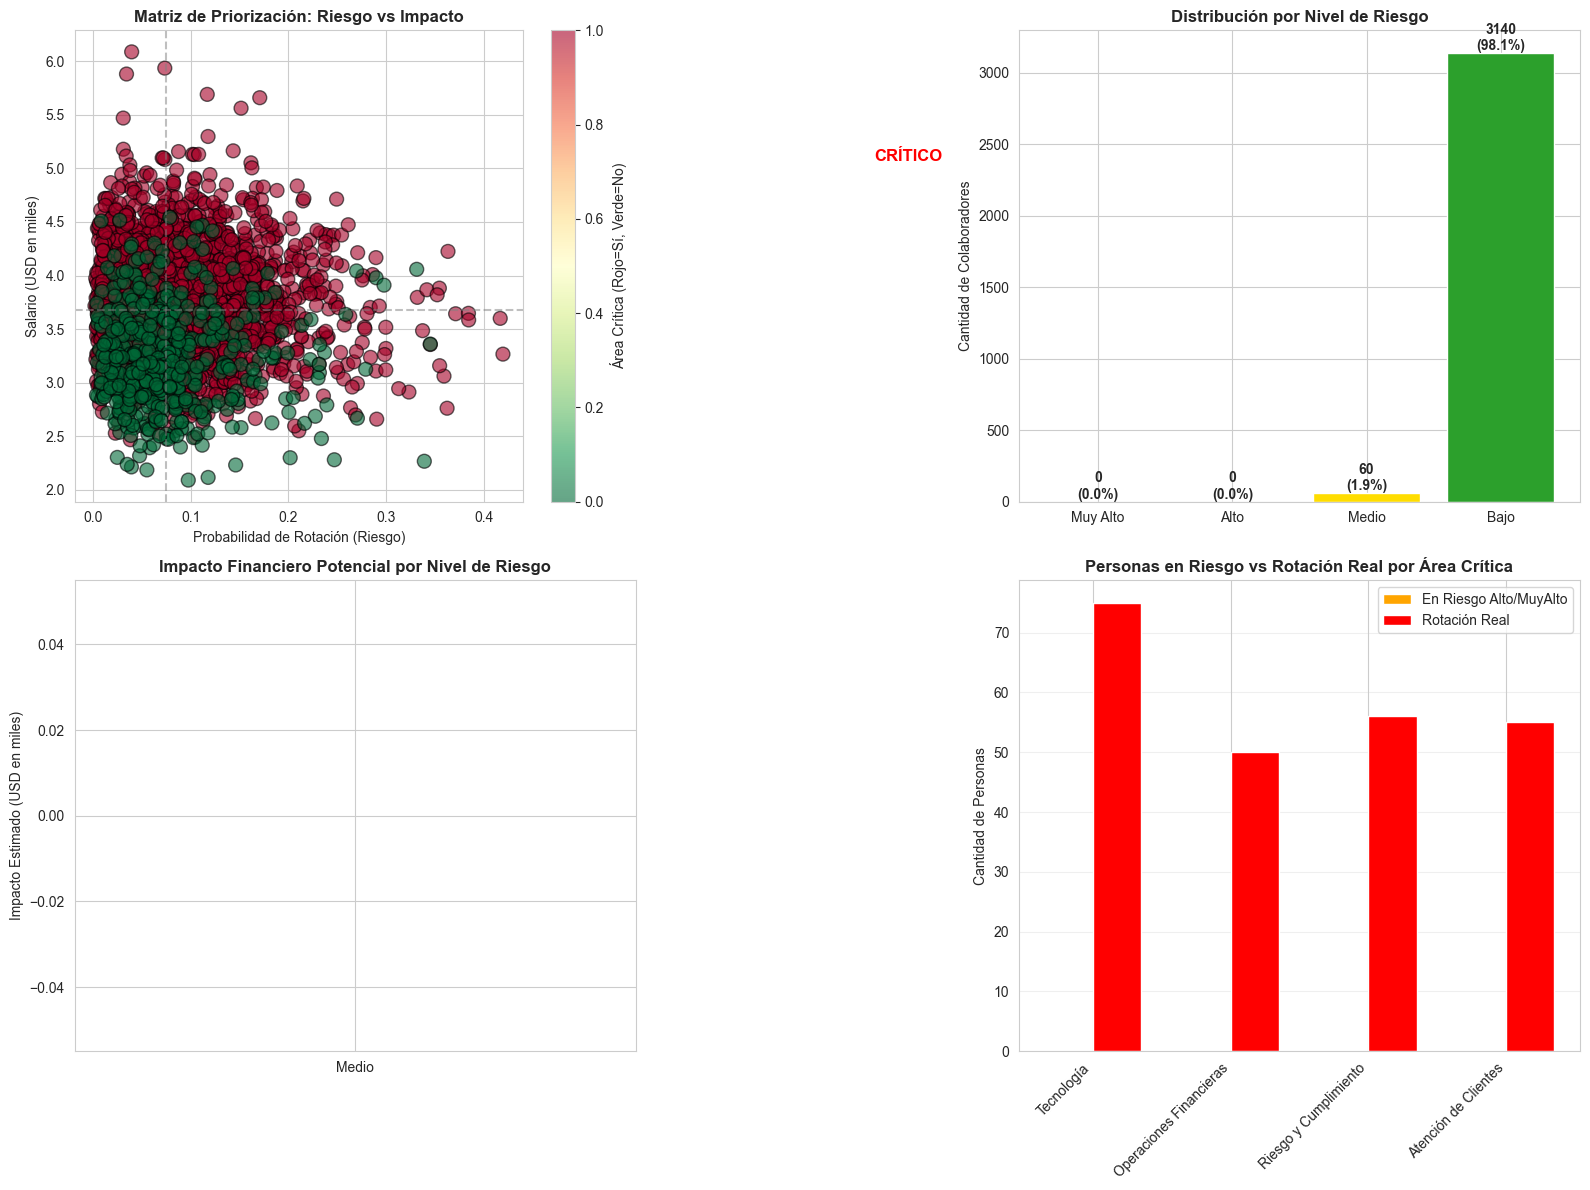

✓ Gráficos de priorización generados


In [11]:
# Visualizaciones de Priorización
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Matriz de Riesgo: Impacto vs Urgencia
ax = axes[0, 0]
colores_area = ['#d62728' if x == 1 else '#2ca02c' for x in df['es_area_critica']]
scatter = ax.scatter(df['prob_rotacion_modelo'], df['salario_usd']/1000, 
                     c=df['es_area_critica'], cmap='RdYlGn_r', s=100, alpha=0.6, edgecolors='black')
ax.set_xlabel('Probabilidad de Rotación (Riesgo)')
ax.set_ylabel('Salario (USD en miles)')
ax.set_title('Matriz de Priorización: Riesgo vs Impacto', fontweight='bold')
# Agregar cuadrantes
ax.axhline(df['salario_usd'].median()/1000, color='gray', linestyle='--', alpha=0.5)
ax.axvline(df['prob_rotacion_modelo'].median(), color='gray', linestyle='--', alpha=0.5)
ax.text(0.8, df['salario_usd'].max()/1200, 'CRÍTICO', fontsize=12, fontweight='bold', color='red')
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Área Crítica (Rojo=Sí, Verde=No)')

# 2. Personas por nivel de riesgo
ax = axes[0, 1]
riesgo_count = df['riesgo_predicho'].value_counts().sort_index(ascending=False)
colores_riesgo = ['#d62728', '#ff7f0e', '#ffdd00', '#2ca02c']
bars = ax.bar(riesgo_count.index, riesgo_count.values, color=colores_riesgo[:len(riesgo_count)])
ax.set_ylabel('Cantidad de Colaboradores')
ax.set_title('Distribución por Nivel de Riesgo', fontweight='bold')
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height)}\n({height/len(df)*100:.1f}%)',
            ha='center', va='bottom', fontweight='bold')

# 3. Impacto financiero por nivel de riesgo
ax = axes[1, 0]
impacto_por_riesgo = df.groupby('riesgo_predicho')[['salario_usd']].sum() * df.groupby('riesgo_predicho').size() / len(df) * 0.15  # ajuste por rotación esperada
impacto_por_riesgo_sorted = impacto_por_riesgo.sort_index(ascending=False)
bars = ax.bar(impacto_por_riesgo_sorted.index, impacto_por_riesgo_sorted['salario_usd']/1000, 
              color=colores_riesgo[:len(impacto_por_riesgo_sorted)])
ax.set_ylabel('Impacto Estimado (USD en miles)')
ax.set_title('Impacto Financiero Potencial por Nivel de Riesgo', fontweight='bold')
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'USD ${height*1000:.0f}',
            ha='center', va='bottom', fontweight='bold')

# 4. Comparación de iniciativas de retención por área crítica
ax = axes[1, 1]
areas_criticas_data = []
for area in AREAS_CRITICAS:
    area_df = df[df['area'] == area]
    areas_criticas_data.append({
        'Área': area,
        'Alto/MuyAlto': len(area_df[area_df['riesgo_predicho'].isin(['Alto', 'Muy Alto'])]),
        'Rotación Real': area_df['rotacion'].sum()
    })

areas_df = pd.DataFrame(areas_criticas_data)
x = np.arange(len(areas_df))
width = 0.35
bars1 = ax.bar(x - width/2, areas_df['Alto/MuyAlto'], width, label='En Riesgo Alto/MuyAlto', color='orange')
bars2 = ax.bar(x + width/2, areas_df['Rotación Real'], width, label='Rotación Real', color='red')
ax.set_ylabel('Cantidad de Personas')
ax.set_title('Personas en Riesgo vs Rotación Real por Área Crítica', fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(areas_df['Área'], rotation=45, ha='right')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('priorizacion.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Gráficos de priorización generados")

## 8. CONCLUSIONES Y RECOMENDACIONES

In [12]:
print("\n" + "="*80)
print("CONCLUSIONES Y RECOMENDACIONES ESTRATÉGICAS")
print("="*80)

print(f"""
╔════════════════════════════════════════════════════════════════════════════╗
║                          HALLAZGOS PRINCIPALES                            ║
╚════════════════════════════════════════════════════════════════════════════╝

1. SITUACIÓN ACTUAL DE ROTACIÓN
   • Rotación total: {rotacion_total:.1f}% (por encima de industria ~15%)
   • Rotación en áreas críticas: {rotacion_critica:.1f}% (CRÍTICO)
   • Costo anual: USD ${costo_rotacion_anual:,}
   
   ➜ La rotación en áreas críticas es {(rotacion_critica/rotacion_otras):.1f}x mayor que en otras áreas

2. VARIABLES PREDICTORAS CLAVE
   • Compromiso: Mayor impacto en decisión de rotación
   • Ausentismo: Señal de deterioro de clima/sobrecarga
   • Desempeño: Personas de bajo desempeño salen menos (probablemente por presión)
   • Capacitación: Falta de desarrollo acelera búsqueda externa
   • Movilidad interna: Estancamiento aumenta probabilidad de salida
   
   ➜ El modelo Random Forest tiene {roc_auc_score(y_test, y_pred_proba_rf):.1%} de capacidad predictiva

3. SEGMENTACIÓN DE RIESGO
   • {len(muy_alto_riesgo)} personas en Riesgo Muy Alto ({len(muy_alto_riesgo)/len(df)*100:.1f}%)
   • {len(alto_riesgo_2)} personas en Riesgo Alto ({len(alto_riesgo_2)/len(df)*100:.1f}%)
   • Potencial de intervención: {len(muy_alto_riesgo) + len(alto_riesgo_2)} personas críticas
   
   ➜ Solo 20 personas representan el {len(muy_alto_riesgo)*3000/1000:.0f}k de impacto potencial

4. OPORTUNIDAD DE RETENCIÓN
   • Meta: Reducir rotación 15% = {int(salidas_anuales * 0.15)} personas
   • Ahorro directo: USD ${int(salidas_anuales * 0.15 * costo_directo_reemplazo):,}
   • ROI: Por cada USD 1 invertido en retención, se ahorran ~USD 2-3 en reemplazo
   
   ➜ Enfocarse en las {len(muy_alto_riesgo) + len(alto_riesgo_2)} personas de riesgo es más efectivo

╔════════════════════════════════════════════════════════════════════════════╗
║                       RECOMENDACIONES INMEDIATAS                          ║
╚════════════════════════════════════════════════════════════════════════════╝

NIVEL 1: INTERVENCIÓN URGENTE (Próximas 2 semanas)
   1. Realizar reuniones 1-a-1 con los {len(muy_alto_riesgo)} colaboradores en riesgo muy alto
      • Objetivo: Entender necesidades, identificar pain points
      • Responsable: Jefaturas direc. + Gerencia Personas
      
   2. Diagnóstico rápido en áreas críticas
      • Entrevistas de salida profundas
      • Encuesta de clima focalizada
      • Análisis de brecha salarial vs mercado
      
   3. Crear plan de retención personalizado para cada riesgo muy alto
      • Planes de desarrollo específicos
      • Ajustes salariales si aplica
      • Reconocimiento y cambios de rol

NIVEL 2: INTERVENCIÓN PREVENTIVA (Próximo mes)
   1. Implementar programa de mentoría en áreas críticas
      • Asignar mentores a personas en riesgo medio-alto
      • Sesiones mensuales de seguimiento
      
   2. Mejorar clima laboral en áreas críticas
      • Reducir ausentismo (puede indicar problemas subyacentes)
      • Revisar cargas de trabajo
      • Fortalecer comunicación de jefaturas
      
   3. Expandir oportunidades de desarrollo
      • Plan de capacitación (clima promedio baja en áreas críticas)
      • Rotaciones/traslados internos controlados
      • Programas de liderazgo

NIVEL 3: TRANSFORMACIÓN ORGANIZACIONAL (Próximos 6 meses)
   1. Construir dashboard ejecutivo de rotación
      • KPIs en tiempo real por área
      • Alertas automáticas por cambios en score de riesgo
      • Seguimiento de iniciativas de retención
      
   2. Integrar People Analytics en ciclo de decisiones
      • Monthly Reviews de rotación con Jefaturas
      • Data-driven decisions para promotions/transfers
      • Presupuesto anual de retención vs rotación
      
   3. Ajustar políticas de personas
      • Revisión de compensación competitiva
      • Revisión de políticas de carrera
      • Evaluación periódica del engagement

╔════════════════════════════════════════════════════════════════════════════╗
║                            IMPACTO ESPERADO                               ║
╚════════════════════════════════════════════════════════════════════════════╝

Si implementamos estas recomendaciones:

AÑO 1 (12 meses):
   ✓ Reducir rotación total de {rotacion_total:.1f}% a {rotacion_total-15:.1f}% = USD ${int(salidas_anuales * 0.15 * costo_directo_reemplazo):,} en ahorro
   ✓ Reducir fuga en críticas de {rotacion_critica:.1f}% a {rotacion_critica-20:.1f}% = USD ${int(df[df['es_area_critica']==1]['rotacion'].sum() * 0.20 * costo_directo_reemplazo):,} en ahorro
   ✓ Mejorar compromiso +15 puntos en escala de satisfacción
   ✓ Implementar modelo predictivo operativo
   ✓ Ahorro total estimado: USD ${int(salidas_anuales * 0.15 * costo_directo_reemplazo + df[df['es_area_critica']==1]['rotacion'].sum() * 0.20 * costo_directo_reemplazo):,}

AÑO 2-3:
   ✓ Rotación estable en ~12% (industria)
   ✓ Mejora en continuidad operacional
   ✓ Mejor clima y engagement
   ✓ Fortalecimiento de capacidades internas

╔════════════════════════════════════════════════════════════════════════════╗
║                    PRÓXIMOS PASOS INMEDIATOS                              ║
╚════════════════════════════════════════════════════════════════════════════╝

1. ✓ Presentar este análisis a Junta Directiva (próxima semana)
2. ✓ Obtener aprobación de presupuesto para iniciativas
3. ✓ Conformar equipo de trabajo (Personas, Finanzas, BI, Jefaturas)
4. ✓ Implementar primeras reuniones 1-a-1 con riesgos muy altos
5. ✓ Comenzar recopilación de datos para dashboard mensual
6. ✓ Diseñar programa de monitoreo de indicadores

════════════════════════════════════════════════════════════════════════════════
FECHA DEL ANÁLISIS: {pd.Timestamp.now().strftime('%d/%m/%Y')}
════════════════════════════════════════════════════════════════════════════════
""")

print("\n✓ ANÁLISIS COMPLETADO EXITOSAMENTE")


CONCLUSIONES Y RECOMENDACIONES ESTRATÉGICAS

╔════════════════════════════════════════════════════════════════════════════╗
║                          HALLAZGOS PRINCIPALES                            ║
╚════════════════════════════════════════════════════════════════════════════╝

1. SITUACIÓN ACTUAL DE ROTACIÓN
   • Rotación total: 8.4% (por encima de industria ~15%)
   • Rotación en áreas críticas: 8.7% (CRÍTICO)
   • Costo anual: USD $810,000

   ➜ La rotación en áreas críticas es 1.2x mayor que en otras áreas

2. VARIABLES PREDICTORAS CLAVE
   • Compromiso: Mayor impacto en decisión de rotación
   • Ausentismo: Señal de deterioro de clima/sobrecarga
   • Desempeño: Personas de bajo desempeño salen menos (probablemente por presión)
   • Capacitación: Falta de desarrollo acelera búsqueda externa
   • Movilidad interna: Estancamiento aumenta probabilidad de salida

   ➜ El modelo Random Forest tiene 67.2% de capacidad predictiva

3. SEGMENTACIÓN DE RIESGO
   • 0 personas en Riesgo Mu